# L2: Prompt Engineering for Image Generation

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [1]:
from IPython.display import Image, Markdown, display
from google import genai
from google.genai import types

In [2]:
import os
from helper import authenticate

credentials, project_id = authenticate()

client = genai.Client(
    project=project_id,
    location="global",
    credentials=credentials,
    http_options=types.HttpOptions(
         base_url=os.getenv("GOOGLE_VERTEX_BASE_URL")
    )
)

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>
</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different run results:</b> The output generated by AI models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

In [3]:
IMAGE_MODEL_ID = "gemini-3.1-flash-image-preview"
TEXT_MODEL_ID = "gemini-3-flash-preview"

## Simple prompt

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> This notebook cell may take a minute to run.</p>

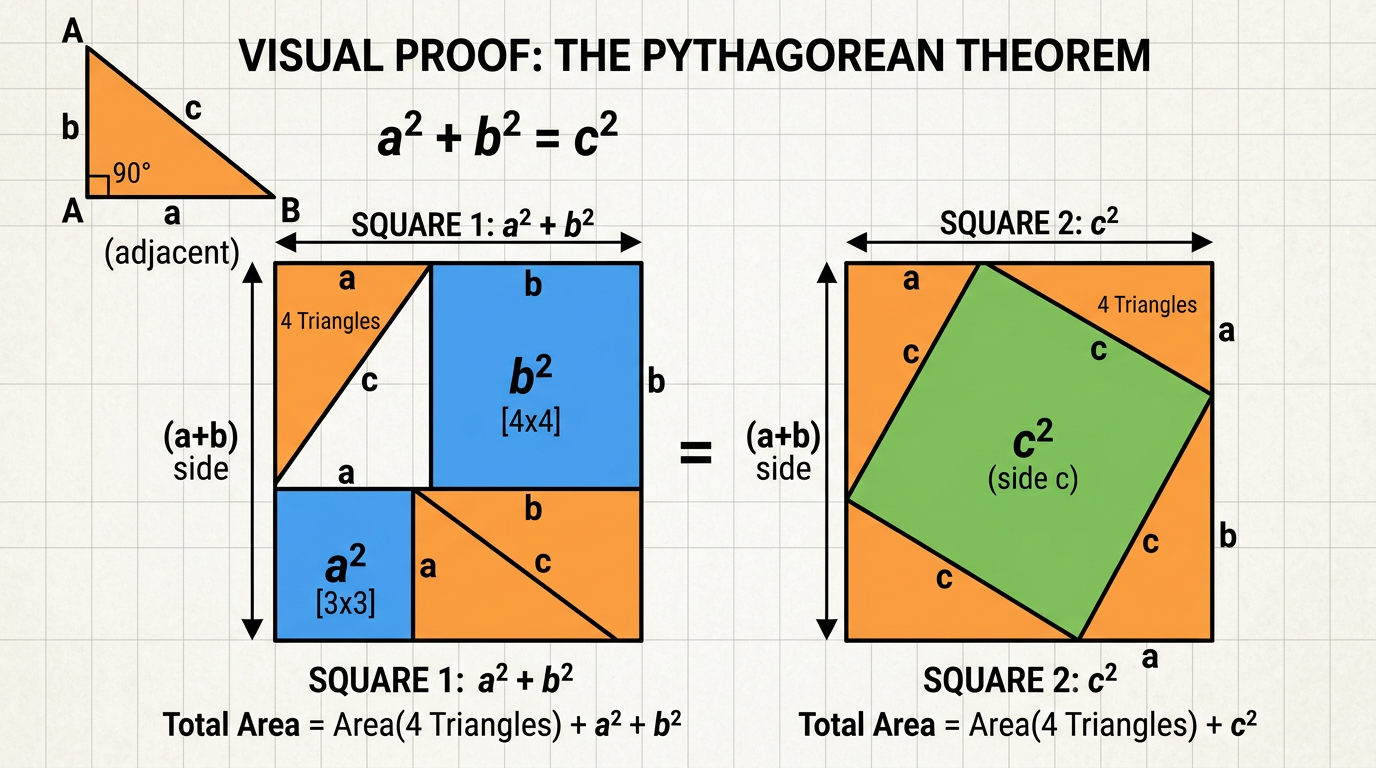

In [4]:
prompt = """
A diagram illustrating visual proof of the Pythagorean theorem.
"""

response = client.models.generate_content(
    model=IMAGE_MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=["IMAGE"],
        image_config=types.ImageConfig(
            # aspect ratios: 1:1, 3:2, 2:3, 3:4, 4:3, 1:4, 4:1, 4:5, 5:4, 1:8, 8:1, 9:16, 16:9, 21:9
            aspect_ratio="16:9",
        ),
    ),

)

for part in response.candidates[0].content.parts:
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

## Prompt enhancement

In [5]:
subject = "a simple slide"
action = "explaining visual proof of the Pythagorean theorem"
location = "white background"
camera_control = "eye-level shot"
lighting = "white light"
style = "minimalist"

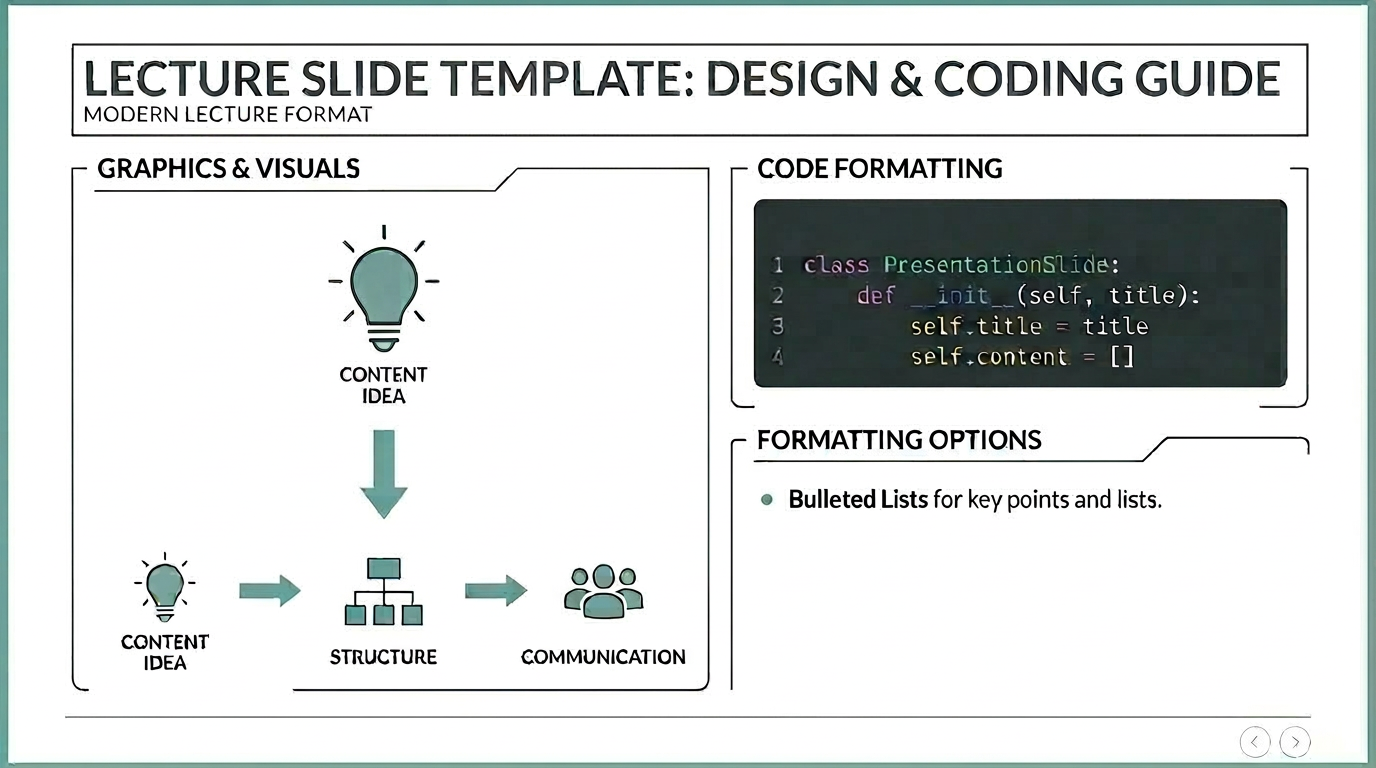

In [6]:
reference_image = "slide-template.png"
display(Image(filename=reference_image, width=500))

In [7]:
keywords = [subject, action, location, camera_control, lighting, style]

gemini_prompt = f"""
Your task is to expand the following keywords into a single, high-fidelity, 
descriptive prompt for image generation. Every single keyword MUST be 
included. Include reference images if provided and use that image as a 
reference style guide for generated images. Output ONLY the final prompt 
string, without any introduction or explanation. Mandatory Keywords: 
{",".join(keywords)}
"""

response = client.models.generate_content(
    model=TEXT_MODEL_ID,
    contents=gemini_prompt,
)

image_prompt = response.text
display(Markdown(response.text))

A minimalist, high-fidelity presentation slide explaining the visual proof of the Pythagorean theorem, featuring a clean geometric diagram of a right-angled triangle with perfectly proportioned squares extending from each of its three sides to illustrate a² + b² = c², set against a pristine solid white background, captured from a direct eye-level shot, illuminated by bright and even white light, characterized by sharp vector lines, elegant mathematical notation, and a simple professional aesthetic.

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> This notebook cell may take a few minutes to run.</p>

In [ ]:
with open(reference_image, "rb") as f:
    image = f.read()

response = client.models.generate_content(
    model=IMAGE_MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=image,
            mime_type="image/png",
        ),
        f"""Use this reference image as a general style guide to generate a lecture 
        slide. Include only the necessary sections from the template. Use the guide 
        as a general style formatting template instead of a strict outline. The 
        slide image should be the entire image. Slide concept: {image_prompt}""",
    ],
    config=types.GenerateContentConfig(
        response_modalities=['IMAGE'],
        image_config=types.ImageConfig(
            aspect_ratio="16:9",
        ),
    ),

)

for part in response.candidates[0].content.parts:
    if part.inline_data:
        image_data=part.inline_data.data
        display(Image(data=image_data, width=500))

with open("slide-image.png", "wb") as image_file:
    image_file.write(image_data)

**Resources**
  - [Get started](https://docs.cloud.google.com/vertex-ai/docs/start/cloud-environment) on Google Cloud
  - Model [documentation](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini/3-1-flash-image)
  - Image [prompting guide](https://cloud.google.com/blog/products/ai-machine-learning/ultimate-prompting-guide-for-nano-banana)